In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [20]:
metadata = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 0, header = 1)
metadata = metadata[2:].reset_index(drop = True)
metadata.columns

Index(['Unnamed: 0', 'Variable', 'CNT_CAT_VAR_MES', 'CNT_SCALAR_MES',
       'CNT_TIME_DATA_MES', 'CNT_TIME_VAR_MES',
       'Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty',
       'Generic.Bioreactor.End Culture.Bolus base.Total Qty',
       'Generic.Bioreactor.End Culture.Cell age at harvest',
       'Generic.Bioreactor.End Culture.Culture duration',
       'Generic.Bioreactor.End Culture.Final VCD',
       'Generic.Bioreactor.End Culture.volume',
       'Generic.Bioreactor.End Culture.PCV',
       'Generic.Bioreactor.Equipment parameters at inoculation.Agitation',
       'Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO primary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO secondary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.Temperature',
       'Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe',
       'G

In [21]:
metadata[["Unnamed: 0", "STR2K_D05_2_1_PA_HPLC_Concentration", "STR2K_D08_2_1_PA_HPLC_Concentration", "STR2K_D14_4_1_PA_HPLC_Concentration"]]

,Unnamed: 0,STR2K_D05_2_1_PA_HPLC_Concentration,STR2K_D08_2_1_PA_HPLC_Concentration,STR2K_D14_4_1_PA_HPLC_Concentration
0,FA001,0.92,2.61,5.19
1,FA002,0.91,2.45,4.86
2,FA003,0.94,2.54,4.63
3,FA004,0.88,2.56,4.62
4,FA005,0.87,2.36,3.91
5,FA006,0.82,2.61,5.63
6,FA007,1.16,3.08,5.79
7,FA008,0.92,2.89,5.89
8,FA009,0.85,2.56,4.84
9,FA010,0.89,2.59,5.56


In [6]:
df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
df.insert(1, "Batch", df["Run"].apply(lambda x: x.split("_")[0]))
df

,Run,Batch,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,FA001,49.646944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,FA001,49.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-PROD 2000L_1003145,FA001,49.746667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN
3,FA001_MCALR N-PROD 2000L_1003145,FA001,49.750556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,101.0,NaN,NaN,NaN,NaN
4,FA001_MCALR N-PROD 2000L_1003145,FA001,49.751944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3322,FA011_MCALR N-PROD 2000L_1004660,FA011,377.617222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2665.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3323,FA011_MCALR N-PROD 2000L_1004660,FA011,377.621111,134.331,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3324,FA011_MCALR N-PROD 2000L_1004660,FA011,377.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3325,FA011_MCALR N-PROD 2000L_1004660,FA011,377.626944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5893.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
first_df = df.groupby("Batch").first().reset_index().copy()

In [24]:
X = first_df[first_df.columns[3:]].tail(6).reset_index(drop = True)
X

,Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,2.909,46.52,10.57,4.651,4873.43,107.87,12.18,0.101,256.33,138.6,7.055,7.04,7.03,97.2,-0.075269,132.2,6.36,87.3
1,2.157,46.38,9.65,4.639,4846.63,101.66,11.45,0.097,269.32,163.4,7.067,7.04,7.03,92.7,-0.087402,134.5,9.46,90.5
2,2.859,46.58,11.07,4.656,4857.81,110.63,12.66,0.090,223.99,126.3,7.039,7.04,7.05,100.7,-0.058965,131.7,7.23,88.1
3,2.909,46.40,8.47,4.642,4902.00,109.24,11.69,0.088,229.67,114.6,7.064,7.03,7.04,95.9,-0.093771,126.2,7.24,89.8
4,2.207,46.40,7.93,4.637,4993.90,109.70,10.97,0.090,234.25,115.6,7.066,7.04,7.04,94.1,-0.086000,130.2,7.23,90.1
5,2.709,46.40,7.64,4.635,4830.23,107.14,15.32,0.089,249.80,138.1,7.069,7.04,7.05,92.0,-0.089000,128.6,7.34,90.4


In [41]:
from scipy.stats import linregress

In [105]:
first_df.columns

Index(['Batch', 'Run', 'Process Time [h]', 'Ammonia [mg/L]',
       'Bolus Feed A Daily Qty [kg]', 'Bolus Glucose Daily Qty [kg]',
       'Bolus Feed B Daily Qty [kg]', 'Glucose [mg/L]', 'Glutamate [mg/L]',
       'Glutamine [mg/L]', 'IgG [g/L]', 'Lactate [mg/L]',
       'LDH [dimensionless]', 'Offline pH preadusjtement [dimensionless]',
       'Online pH primary probe preadusjtement [dimensionless]',
       'Online pH secondary probe preadusjtement [dimensionless]',
       'pCO2 preadusjtement [mmHg]', 'pH offset []',
       'pO2 preadusjtement [mmHg]', 'VCD [Mc/mL]', 'Viability [%]'],
      dtype='object')

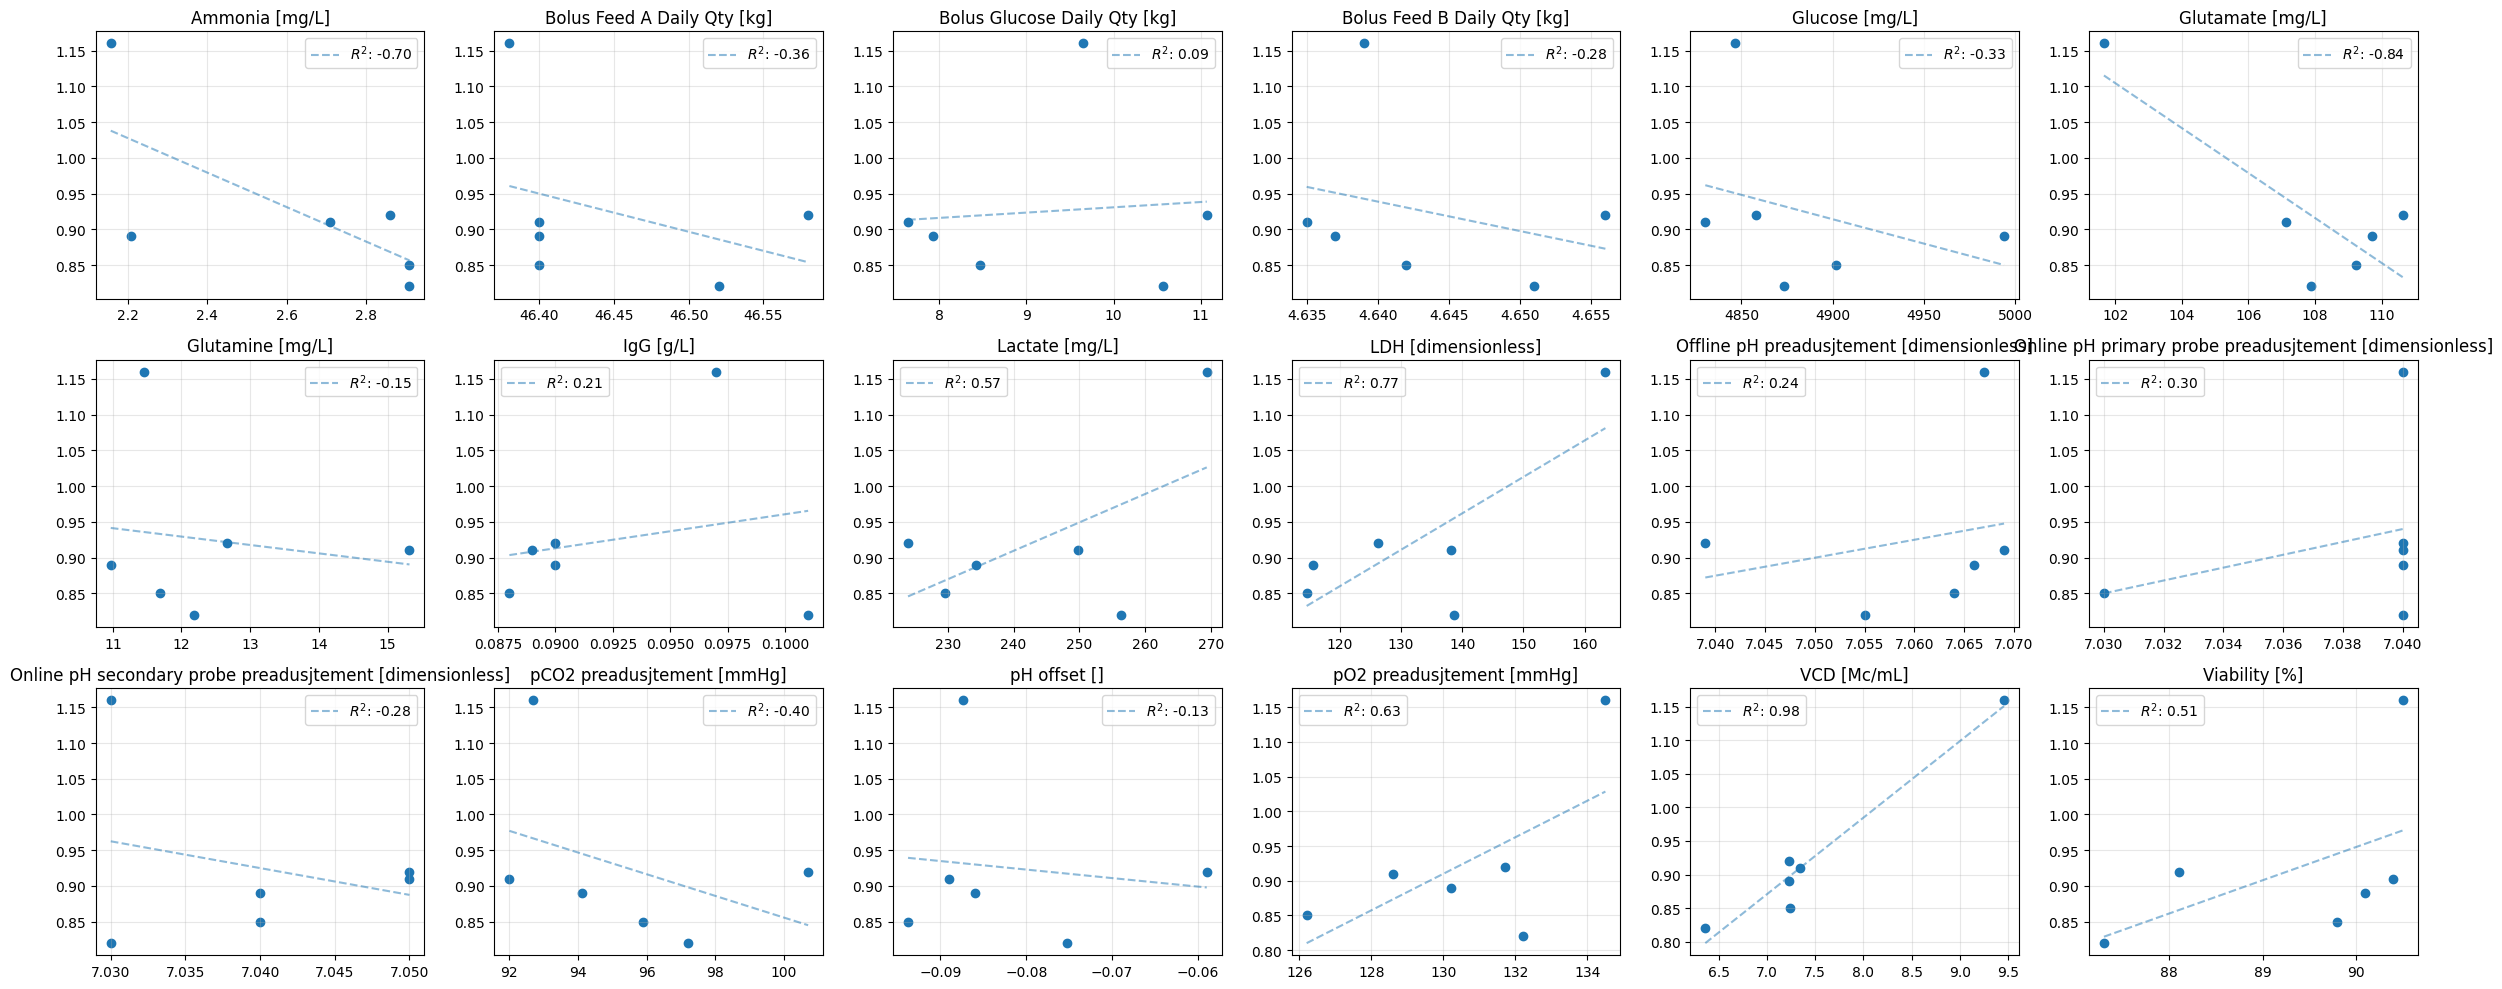

In [62]:
fig, axs = plt.subplots(3, 6, figsize = (24, 10))
r2_df = []
y = metadata["STR2K_D05_2_1_PA_HPLC_Concentration"][-6:].tolist()
for i in range(len(X.columns)):
    row_idx = i // 6
    col_idx = i % 6
    ax = axs[row_idx][col_idx]

    results = linregress(X[X.columns[i]], y)
    m, b = results.slope, results.intercept
    rvalue = results.rvalue
    
    ax.scatter(
        X[X.columns[i]],
        y
    )
    ends = [X[X.columns[i]].min(), X[X.columns[i]].max()] 
    ax.plot(
        ends,
        [m*i + b for i in ends],
        linestyle = '--',
        alpha = 0.5,
        label = f"$R^2$: {rvalue:.2f}"
    )
    ax.set_title(X.columns[i])

    r2_df.append([X.columns[i], rvalue])

    ax.grid(alpha = 0.3)
    ax.legend()
r2_df = pd.DataFrame(r2_df, columns = ["Feature", "R Value"])
r2_df["R Value Abs"] = r2_df["R Value"].abs()
fig.tight_layout()
fig.savefig("./nstep_first.png")

In [63]:
r2_df.sort_values(by = "R Value Abs", ascending = False).head(5)

,Feature,R Value,R Value Abs
16,VCD [Mc/mL],0.976097,0.976097
5,Glutamate [mg/L],-0.835870,0.835870
9,LDH [dimensionless],0.768775,0.768775
0,Ammonia [mg/L],-0.699999,0.699999
15,pO2 preadusjtement [mmHg],0.632693,0.632693


In [67]:
df2 = pd.read_excel("./data/mCALR N-1.xlsx", sheet_name = 1)
df2.insert(1, "Batch", df2["Run"].apply(lambda x: x.split("_")[0]))
df2

,Run,Batch,Process Time [h],Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-1 STR200L_1003102,FA001,120.770278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
1,FA001_MCALR N-1 STR200L_1003102,FA001,120.788056,NaN,NaN,NaN,NaN,NaN,NaN,7.091,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-1 STR200L_1003102,FA001,120.790000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,106.0,NaN,NaN,NaN
3,FA001_MCALR N-1 STR200L_1003102,FA001,120.791389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.9,NaN,NaN
4,FA001_MCALR N-1 STR200L_1003102,FA001,124.284722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,FA011_MCALR N-1 STR200L_1004732,FA011,232.118333,NaN,2605.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1200,FA011_MCALR N-1 STR200L_1004732,FA011,232.121667,NaN,NaN,NaN,37.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1201,FA011_MCALR N-1 STR200L_1004732,FA011,232.123611,NaN,NaN,21.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202,FA011_MCALR N-1 STR200L_1004732,FA011,232.127778,NaN,NaN,NaN,NaN,1140.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
first_df2 = df2.groupby("Batch").last().reset_index().copy()
X = first_df2[first_df2.columns[3:]].tail(6).reset_index(drop = True)
X

,Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,6.471,2815.61,10.12,33.92,1049.13,631.2,6.868,6.81,72.2,10.0,69.72,86.80
1,5.417,2811.73,2.07,30.54,1001.86,535.1,6.868,6.80,82.1,10.0,50.41,79.90
2,6.521,2522.68,17.00,34.16,1028.29,550.7,6.882,6.82,80.1,10.0,63.90,83.80
3,6.320,2772.07,15.37,34.65,1033.27,584.6,6.882,6.82,76.4,10.0,65.54,89.70
4,4.163,3415.97,16.54,38.03,1084.51,525.9,6.896,6.84,73.5,10.0,60.63,91.30
5,5.267,2605.75,21.19,37.79,1140.95,576.4,6.856,6.80,79.5,10.0,59.01,90.77


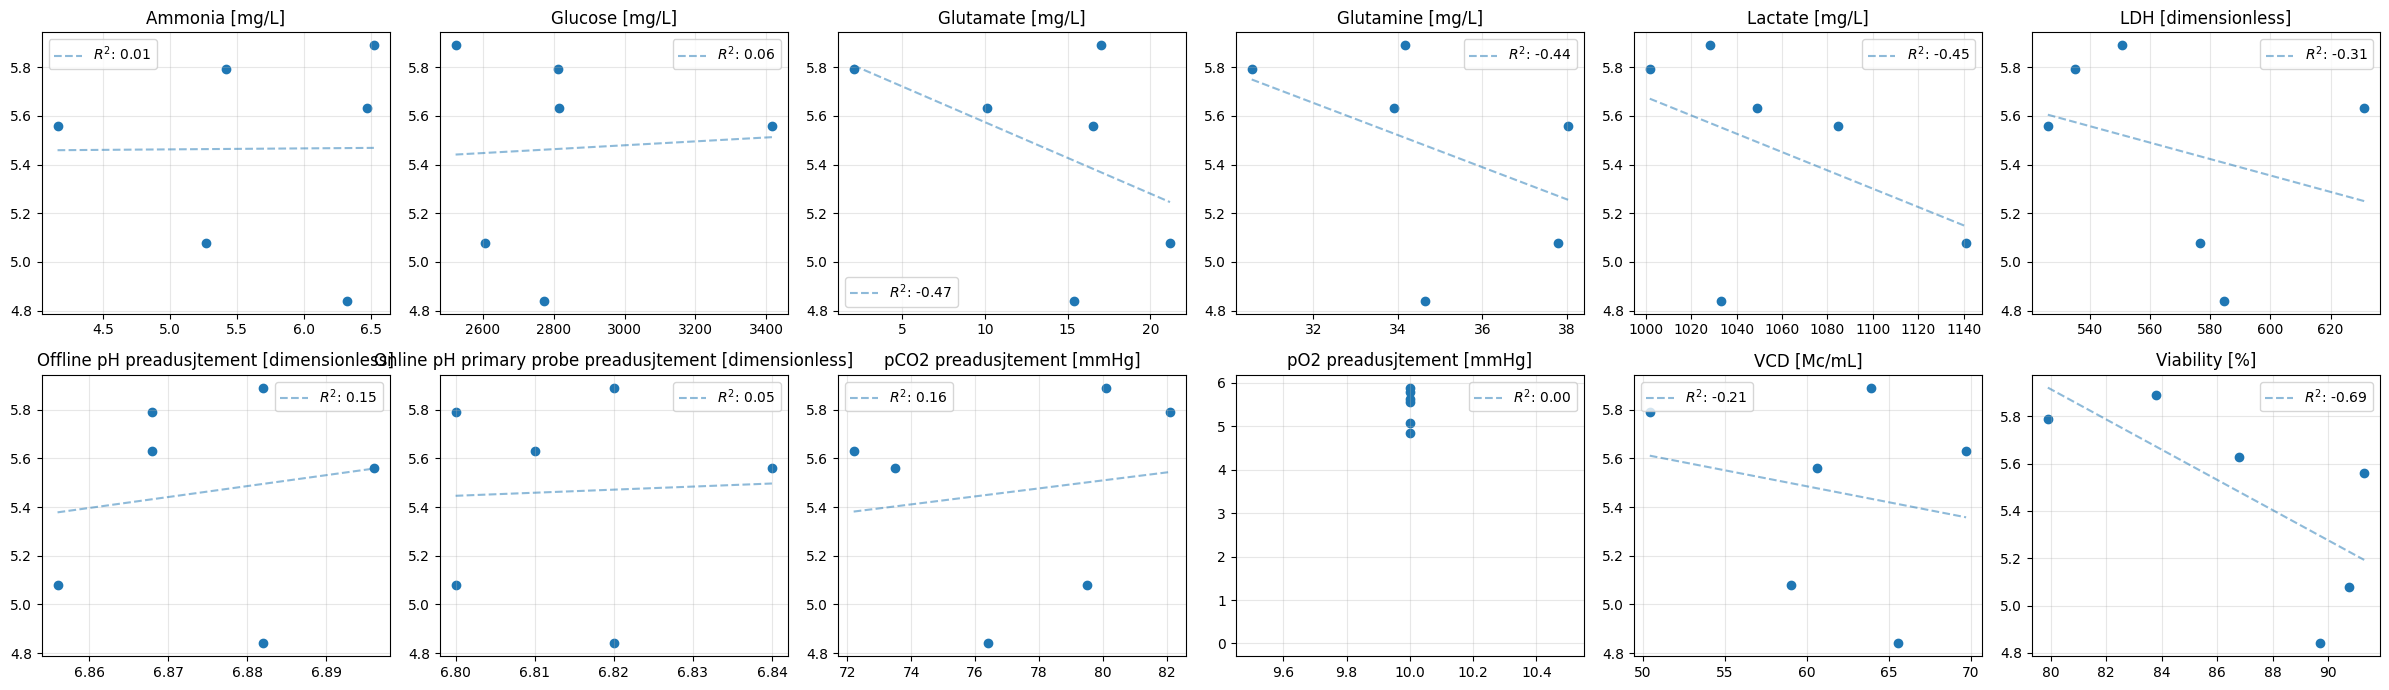

In [81]:
fig, axs = plt.subplots(2, 6, figsize = (24, 7))
r2_df = []
y = metadata["STR2K_D14_4_1_PA_HPLC_Concentration"][-6:].tolist()
for i in range(len(X.columns)):
    row_idx = i // 6
    col_idx = i % 6
    ax = axs[row_idx][col_idx]

    try:
        results = linregress(X[X.columns[i]], y)
        m, b = results.slope, results.intercept
        rvalue = results.rvalue
    except:
        m, b, rvalue = 0, 0, 0
    
    ax.scatter(
        X[X.columns[i]],
        y
    )
    ends = [X[X.columns[i]].min(), X[X.columns[i]].max()] 
    ax.plot(
        ends,
        [m*i + b for i in ends],
        linestyle = '--',
        alpha = 0.5,
        label = f"$R^2$: {rvalue:.2f}"
    )
    ax.set_title(X.columns[i])

    r2_df.append([X.columns[i], rvalue])

    ax.grid(alpha = 0.3)
    ax.legend()
r2_df = pd.DataFrame(r2_df, columns = ["Feature", "R Value"])
r2_df["R Value Abs"] = r2_df["R Value"].abs()
fig.tight_layout()
fig.savefig("./nminusstep_first.png")

In [82]:
r2_df.sort_values(by = "R Value Abs", ascending = False).head(5)

,Feature,R Value,R Value Abs
11,Viability [%],-0.690611,0.690611
2,Glutamate [mg/L],-0.474961,0.474961
4,Lactate [mg/L],-0.449945,0.449945
3,Glutamine [mg/L],-0.441982,0.441982
5,LDH [dimensionless],-0.314022,0.314022


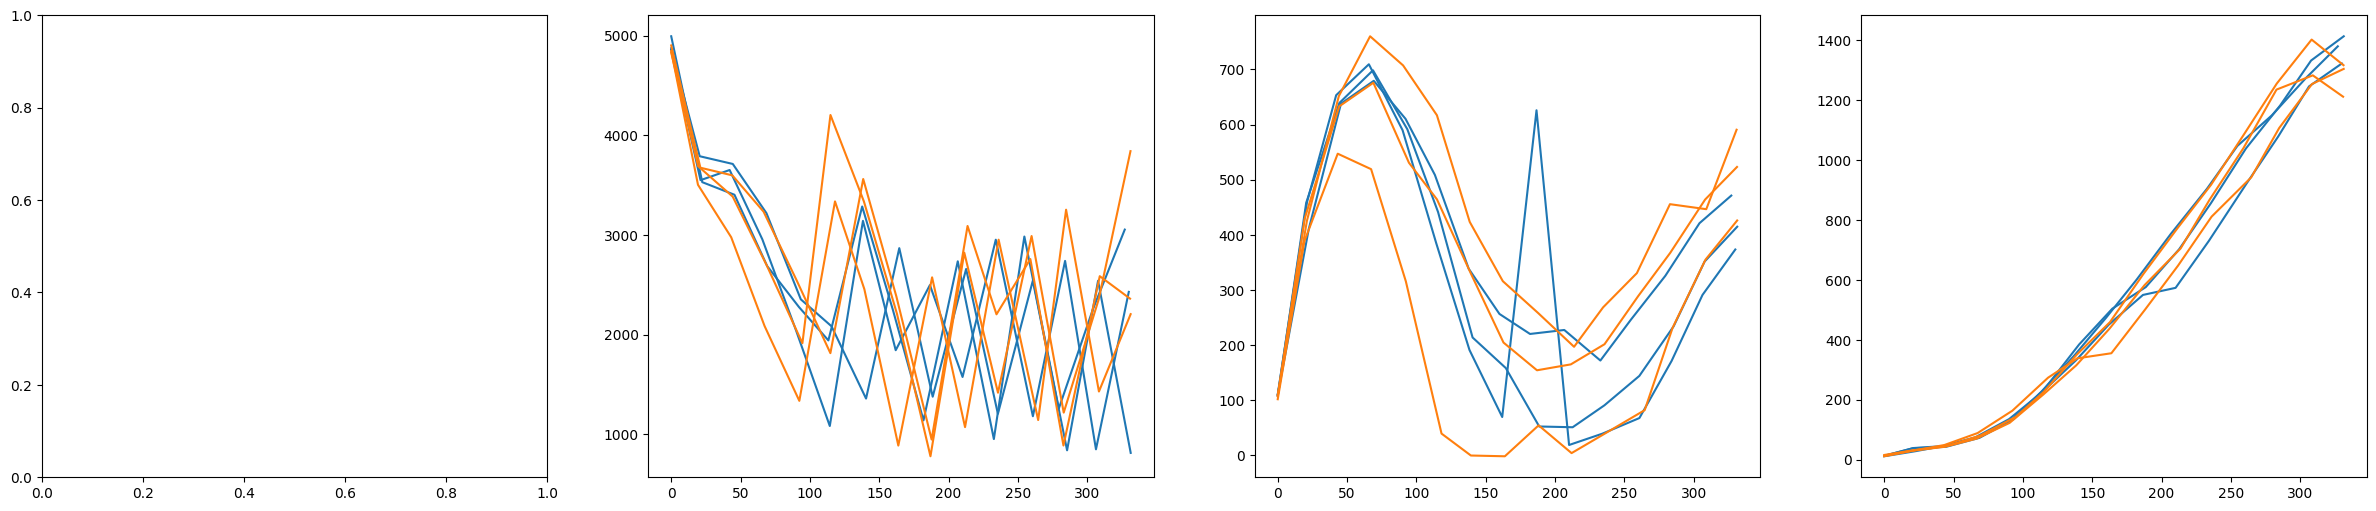

In [103]:
fig, axs = plt.subplots(1, 4, figsize = (30, 6))

# glucose Glutamate glutamine
feats = [
    "Glucose [mg/L]",
    "Glutamate [mg/L]",
    "Glutamine [mg/L]"
]
batches = ["FA006", "FA008", "FA010", "FA007", "FA009", "FA011"]
colors  = ["C0", "C0", "C0", "C1", "C1", "C1"]

for feat_idx, feat in enumerate(feats):
    ax = axs[feat_idx + 1]
    for batch_idx, batch in enumerate(batches):
        sub_df = df[df["Batch"] == batch].copy()
        sub_df = sub_df[["Process Time [h]", feat]]
        sub_df = sub_df[~sub_df[feat].isna()]
        sub_df["Process Time [h]"] = sub_df["Process Time [h]"] - sub_df["Process Time [h]"].min()
        # sub_df = sub_df[sub_df["Process Time [h]"] <= 120]
        ax.plot(sub_df["Process Time [h]"], sub_df[feat], color = colors[batch_idx])

In [89]:
df.iloc[0].T

Run                                                         FA001_MCALR N-PROD 2000L_1003145
Batch                                                                                  FA001
Process Time [h]                                                                   49.646944
Ammonia [mg/L]                                                                           NaN
Bolus Feed A Daily Qty [kg]                                                              NaN
Bolus Glucose Daily Qty [kg]                                                             NaN
Bolus Feed B Daily Qty [kg]                                                              NaN
Glucose [mg/L]                                                                           NaN
Glutamate [mg/L]                                                                         NaN
Glutamine [mg/L]                                                                         NaN
IgG [g/L]                                                             